# Permutation testing

Outcomes: SP volume difference, WM surface area difference.  
Predictors per paper: `GA`, `qa_mean` (mean quality across the pair), `stack_count`.

**Changes from v1 (based on feedback):**
- Dropped SNR-derived `sh_sp_diff` and boundary-CR `cnr_diff` covariates — they were uninformative in the v1 fits.
- Replaced `qa_diff` (absolute QA difference within the pair) with `qa_mean` (mean QA of the pair). The within-pair difference carried little signal; the pair-level mean is a cleaner reliability covariate.
- After these changes, the former `M_SH` and `M_CNR` collapse into the same model and are reported once as `M_acq`.
- Restricted sample to **GA ≤ 32 weeks** (drops 3 late-GA subjects: FCB070, FCB184, FCB187). N goes from 23 → 20 per pair.

**Two split pairs (S1-S2, S3-S4) treated as independent replications**, fit separately. The right way to read the results is *consistency across pairs*, not which pair has the highest R².

Diagnostics (predicted vs actual, residuals vs fitted, QQ-plot, residuals vs GA) are shown directly under each model's forest plot.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from slides_helpers import diagnostics_grid, fit_and_present, model_comparison_table

DATA = Path('../data')
ASSETS = Path('../assets')
ASSETS.mkdir(exist_ok=True)

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

## Load data and build per-pair analysis frames

Three CSVs:
- `raw_subject_data.csv` — `stack_count`, `QA_S1..S4`, `QA12_mean`, `QA34_mean`, `GA`
- `split_comparision_data.csv` — per split-pair: `abs_diff_sp`, `rel_diff_sp`, `wm_surface_area_diff`, `wm_surface_area_mean`, `cnr_diff`, `cnr_mean`
- `image_quality_metrics.csv` — per split: `snr_subplate` (mean/SD within mask — surface homogeneity, NOT classical SNR), `sp_iz_cnr` (boundary CR — already aggregated to `cnr_diff`/`cnr_mean` above)

In [2]:
raw = pd.read_csv(DATA / 'raw_subject_data.csv')
splits_df = pd.read_csv(DATA / 'split_comparision_data.csv')
iqm = pd.read_csv(DATA / 'image_quality_metrics.csv')

# Restrict to GA <= 32 weeks (drops 3 late-GA subjects: FCB070, FCB184, FCB187)
GA_MAX = 32
_keep = raw.loc[raw['GA'] <= GA_MAX, ['subject_id', 'session_id']]
raw = raw.merge(_keep, on=['subject_id', 'session_id'], how='inner')
splits_df = splits_df.merge(_keep, on=['subject_id', 'session_id'], how='inner')
iqm = iqm.merge(_keep, on=['subject_id', 'session_id'], how='inner')

print('raw:', raw.shape, '| splits:', splits_df.shape, '| iqm:', iqm.shape)

# QA differences within each pair (paper's 'quality difference')
raw['qa_diff_S1S2'] = (raw['QA_S1'] - raw['QA_S2']).abs()
raw['qa_diff_S3S4'] = (raw['QA_S3'] - raw['QA_S4']).abs()

# Surface-homogeneity (SH) differences within each pair, on subplate mask
sh_wide = iqm.pivot_table(
    index=['subject_id', 'session_id'],
    columns='split',
    values='snr_subplate',
).reset_index()
sh_wide['sh_sp_diff_S1S2'] = (sh_wide['S1'] - sh_wide['S2']).abs()
sh_wide['sh_sp_diff_S3S4'] = (sh_wide['S3'] - sh_wide['S4']).abs()
sh_wide = sh_wide[['subject_id', 'session_id', 'sh_sp_diff_S1S2', 'sh_sp_diff_S3S4']]

def build_pair(label):
    pair_tag = label.replace('-', '')  # 'S1S2'
    df = (
        splits_df[splits_df['split_pair'] == label]
        .merge(raw[['subject_id', 'session_id', 'stack_count',
                    f'qa_diff_{pair_tag}',
                    f'QA{pair_tag[1] + pair_tag[3]}_mean']],
               on=['subject_id', 'session_id'], how='left')
        .merge(sh_wide[['subject_id', 'session_id', f'sh_sp_diff_{pair_tag}']],
               on=['subject_id', 'session_id'], how='left')
        .rename(columns={f'qa_diff_{pair_tag}': 'qa_diff',
                         f'QA{pair_tag[1] + pair_tag[3]}_mean': 'qa_mean',
                         f'sh_sp_diff_{pair_tag}': 'sh_sp_diff'})
    )
    # APD (absolute percent difference) — paper's reliability metric
    df['apd_sp'] = df['rel_diff_sp']  # already computed as rel diff in pipeline
    df['apd_surface'] = (df['wm_surface_area_diff']
                          / df['wm_surface_area_mean'] * 100)
    return df

s12 = build_pair('S1-S2')
s34 = build_pair('S3-S4')

print('\nS1-S2 frame:', s12.shape)
print('S3-S4 frame:', s34.shape)
display(s12.head(3))

raw: (20, 11) | splits: (40, 16) | iqm: (80, 25)

S1-S2 frame: (20, 22)
S3-S4 frame: (20, 22)


,subject_id,session_id,GA,split_pair,abs_diff_sp,abs_diff_cp,abs_diff_inner,abs_diff_total,rel_diff_sp,rel_diff_cp,...,cnr_diff,cnr_mean,wm_surface_area_diff,wm_surface_area_mean,stack_count,qa_diff,qa_mean,sh_sp_diff,apd_sp,apd_surface
0,1109332,MR-EI_Fetal_Body-26810110-20230404,27.000,S1-S2,234.127,680.279,2088.988,1642.836,0.907,2.251,...,0.002,0.011,1035.265,17384.387,3,0.080,0.540,0.230,0.907,5.955
1,4712320,MR-EI_Fetal_Body-26831832-20230502,30.400,S1-S2,191.251,302.062,1019.166,1129.977,0.448,0.549,...,0.002,0.008,1624.870,28397.498,5,0.050,0.730,0.088,0.448,5.722
2,5552729,MR-EI_Fetal_Neuro-26149163-20210623,26.100,S1-S2,805.681,278.453,1965.108,2492.336,3.499,1.046,...,0.003,0.015,285.124,15146.900,11,0.090,0.610,0.722,3.499,1.882


## Layer 1 — Reliability magnitude (descriptive)

Paper-style summary: APD (mean ± SD, range) for both outcomes and both pairs.

In [3]:
def reliability_row(df, abs_col, apd_col, label, pair):
    a = df[abs_col].dropna()
    p = df[apd_col].dropna()
    return {
        'metric': label, 'pair': pair, 'N': len(a),
        'abs_mean': a.mean().round(2), 'abs_sd': a.std().round(2),
        'abs_range': f'[{a.min():.1f}, {a.max():.1f}]',
        'APD_mean': p.mean().round(2), 'APD_sd': p.std().round(2),
        'APD_range': f'[{p.min():.2f}, {p.max():.2f}]',
    }

rows = [
    reliability_row(s12, 'abs_diff_sp', 'apd_sp', 'SP volume (mm³)', 'S1-S2'),
    reliability_row(s34, 'abs_diff_sp', 'apd_sp', 'SP volume (mm³)', 'S3-S4'),
    reliability_row(s12, 'wm_surface_area_diff', 'apd_surface', 'WM surface area (mm²)', 'S1-S2'),
    reliability_row(s34, 'wm_surface_area_diff', 'apd_surface', 'WM surface area (mm²)', 'S3-S4'),
]
reliability_table = pd.DataFrame(rows)
reliability_table.to_csv(ASSETS / 'reliability_summary_table.csv', index=False)
display(reliability_table)
print('Saved → assets/reliability_summary_table.csv')

,metric,pair,N,abs_mean,abs_sd,abs_range,APD_mean,APD_sd,APD_range
0,SP volume (mm³),S1-S2,20,554.410,504.220,"[23.6, 1793.3]",1.630,1.420,"[0.07, 4.95]"
1,SP volume (mm³),S3-S4,20,486.290,538.620,"[1.6, 1694.8]",1.260,1.170,"[0.01, 4.00]"
2,WM surface area (mm²),S1-S2,20,223.390,402.720,"[0.6, 1624.9]",1.050,1.720,"[0.00, 5.96]"
3,WM surface area (mm²),S3-S4,20,125.830,136.930,"[4.2, 609.0]",0.610,0.760,"[0.03, 3.58]"


Saved → assets/reliability_summary_table.csv


## Volume models

Two specifications, each fit independently for S1-S2 and S3-S4:
1. **M_GA** (baseline): `vol_diff_sp ~ GA`
2. **M_acq** (paper-style acquisition factors): `vol_diff_sp ~ GA + qa_mean + stack_count`


===  | S1-S2 | R²=0.160 | F=3.42 | p=0.0809 | N=20 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-1873.492,1317.047,-1.420,0.172,-4640.510,893.520,
GA,86.925,47.000,1.850,0.081,-11.820,185.670,



===  | S3-S4 | R²=0.239 | F=5.66 | p=0.0286 | N=20 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-2687.749,1338.704,-2.010,0.060,-5500.260,124.760,
GA,113.639,47.773,2.380,0.029,13.270,214.010,*


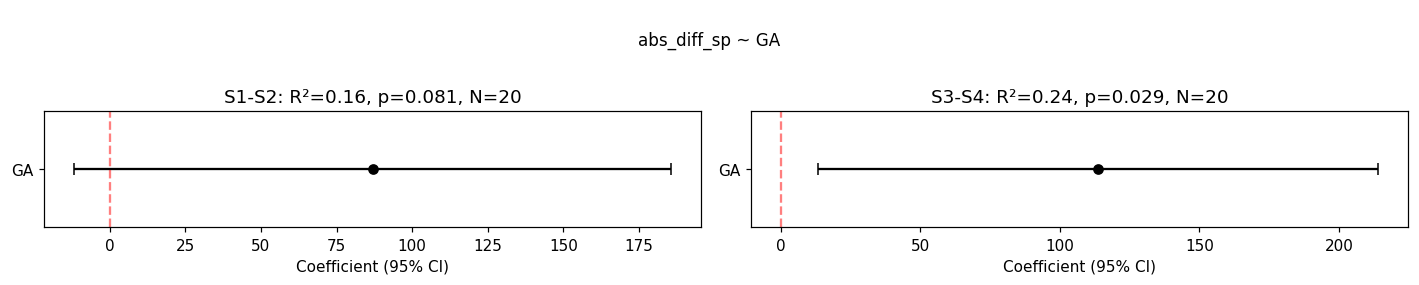

In [4]:
vol_results = {}

vol_results['M_GA (vol)'] = fit_and_present(
    'abs_diff_sp', ['GA'], s12, s34,
    '', 'vol_M_GA', ASSETS,
)


[M_GA — SP volume baseline] S1-S2 — top 3 outliers (|studentized residual|):
  1. FCB195/MR-EI_Fetal_Neuro-26792482-20230322  studentized_resid=+2.34  resid=+1.06e+03  fitted=734  actual=1.79e+03
  2. FCB117/2018.03.01-032Y-MR_EI_Fetal_Neuro-18053  studentized_resid=+2.03  resid=+930  fitted=685  actual=1.61e+03
  3. FCB168/2020.03.12-021Y-MR_EI_Fetal_Neuro-30926  studentized_resid=-1.83  resid=-802  fitted=833  actual=31

[M_GA — SP volume baseline] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB139/2019.01.31-032Y-MR_EI_Fetal_Neuro-29172  studentized_resid=+2.35  resid=+1.1e+03  fitted=592  actual=1.69e+03
  2. FCB168/2020.03.12-021Y-MR_EI_Fetal_Neuro-30926  studentized_resid=-1.83  resid=-814  fitted=851  actual=36.7
  3. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+1.66  resid=+770  fitted=688  actual=1.46e+03


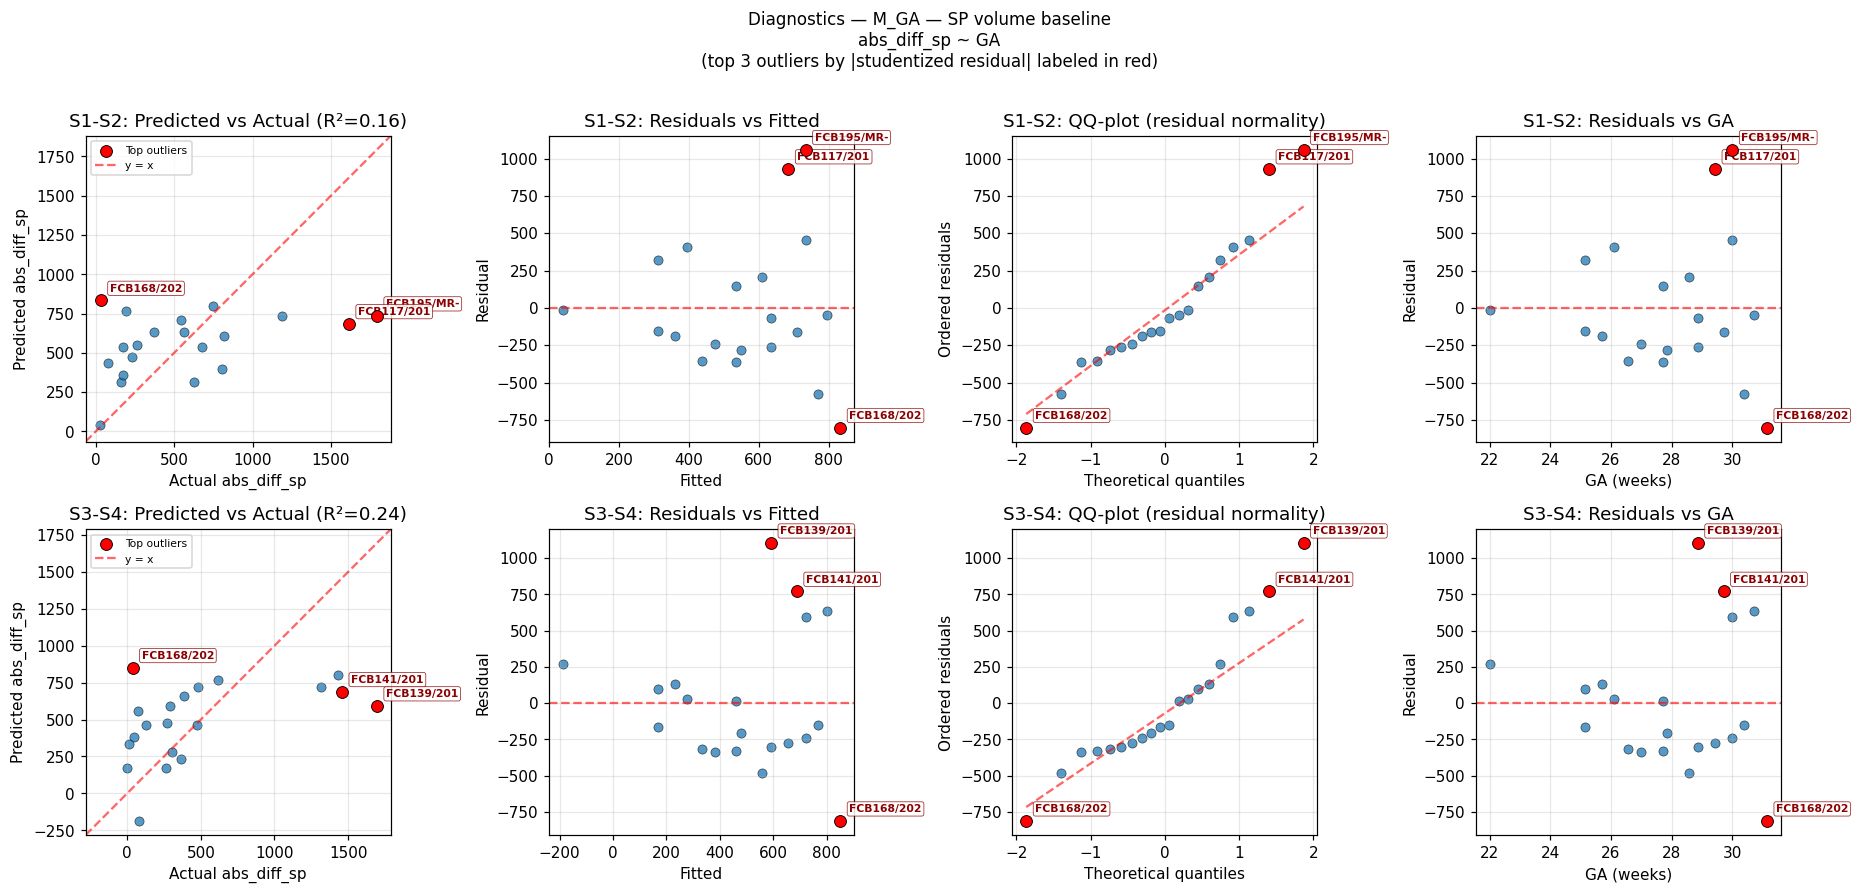

In [5]:
diagnostics_grid(
    vol_results['M_GA (vol)'], s12, s34,
    'abs_diff_sp', ['GA'],
    'M_GA — SP volume baseline',
)
plt.show()


===  | S1-S2 | R²=0.280 | F=2.08 | p=0.1436 | N=20 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-1546.341,1482.098,-1.040,0.312,-4688.250,1595.570,
GA,94.333,46.682,2.020,0.060,-4.630,193.290,
qa_mean,-981.609,734.972,-1.340,0.200,-2539.680,576.460,
stack_count,14.431,39.911,0.360,0.722,-70.180,99.040,



===  | S3-S4 | R²=0.284 | F=2.11 | p=0.1389 | N=20 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-3431.796,1568.565,-2.190,0.044,-6757.010,-106.590,*
GA,115.031,50.078,2.300,0.035,8.870,221.190,*
qa_mean,673.739,967.820,0.700,0.496,-1377.950,2725.420,
stack_count,40.634,43.238,0.940,0.361,-51.030,132.300,


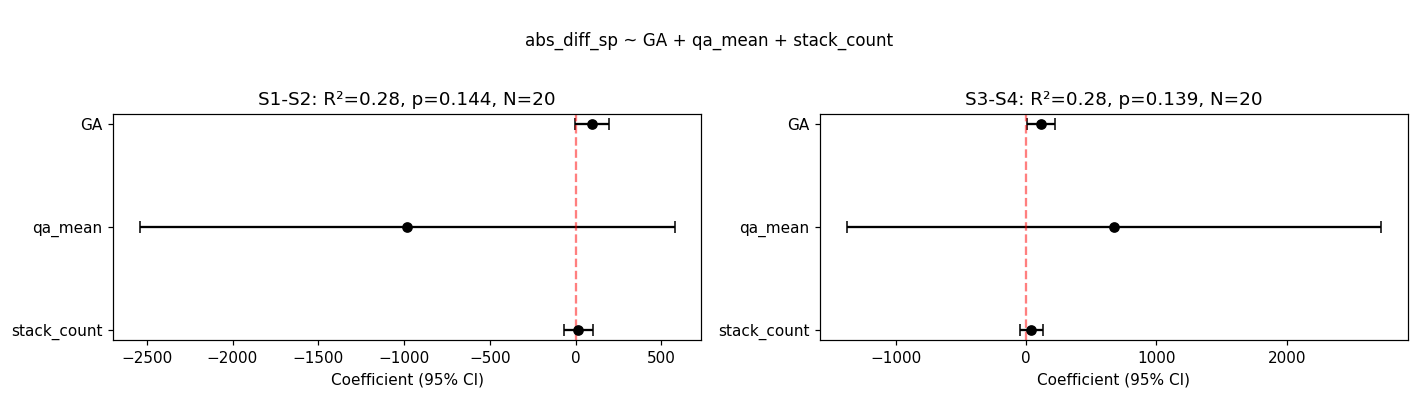

In [6]:
vol_results['M_acq (vol)'] = fit_and_present(
    'abs_diff_sp', ['GA', 'qa_mean', 'stack_count'], s12, s34,
    '', 'vol_M_acq', ASSETS,
)


[M_acq — SP volume + acquisition factors] S1-S2 — top 3 outliers (|studentized residual|):
  1. FCB195/MR-EI_Fetal_Neuro-26792482-20230322  studentized_resid=+2.66  resid=+1.12e+03  fitted=669  actual=1.79e+03
  2. FCB168/2020.03.12-021Y-MR_EI_Fetal_Neuro-30926  studentized_resid=-1.97  resid=-843  fitted=874  actual=31
  3. FCB117/2018.03.01-032Y-MR_EI_Fetal_Neuro-18053  studentized_resid=+1.46  resid=+559  fitted=1.06e+03  actual=1.61e+03

[M_acq — SP volume + acquisition factors] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB139/2019.01.31-032Y-MR_EI_Fetal_Neuro-29172  studentized_resid=+2.44  resid=+1.17e+03  fitted=529  actual=1.69e+03
  2. FCB168/2020.03.12-021Y-MR_EI_Fetal_Neuro-30926  studentized_resid=-1.78  resid=-809  fitted=846  actual=36.7
  3. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+1.54  resid=+730  fitted=728  actual=1.46e+03


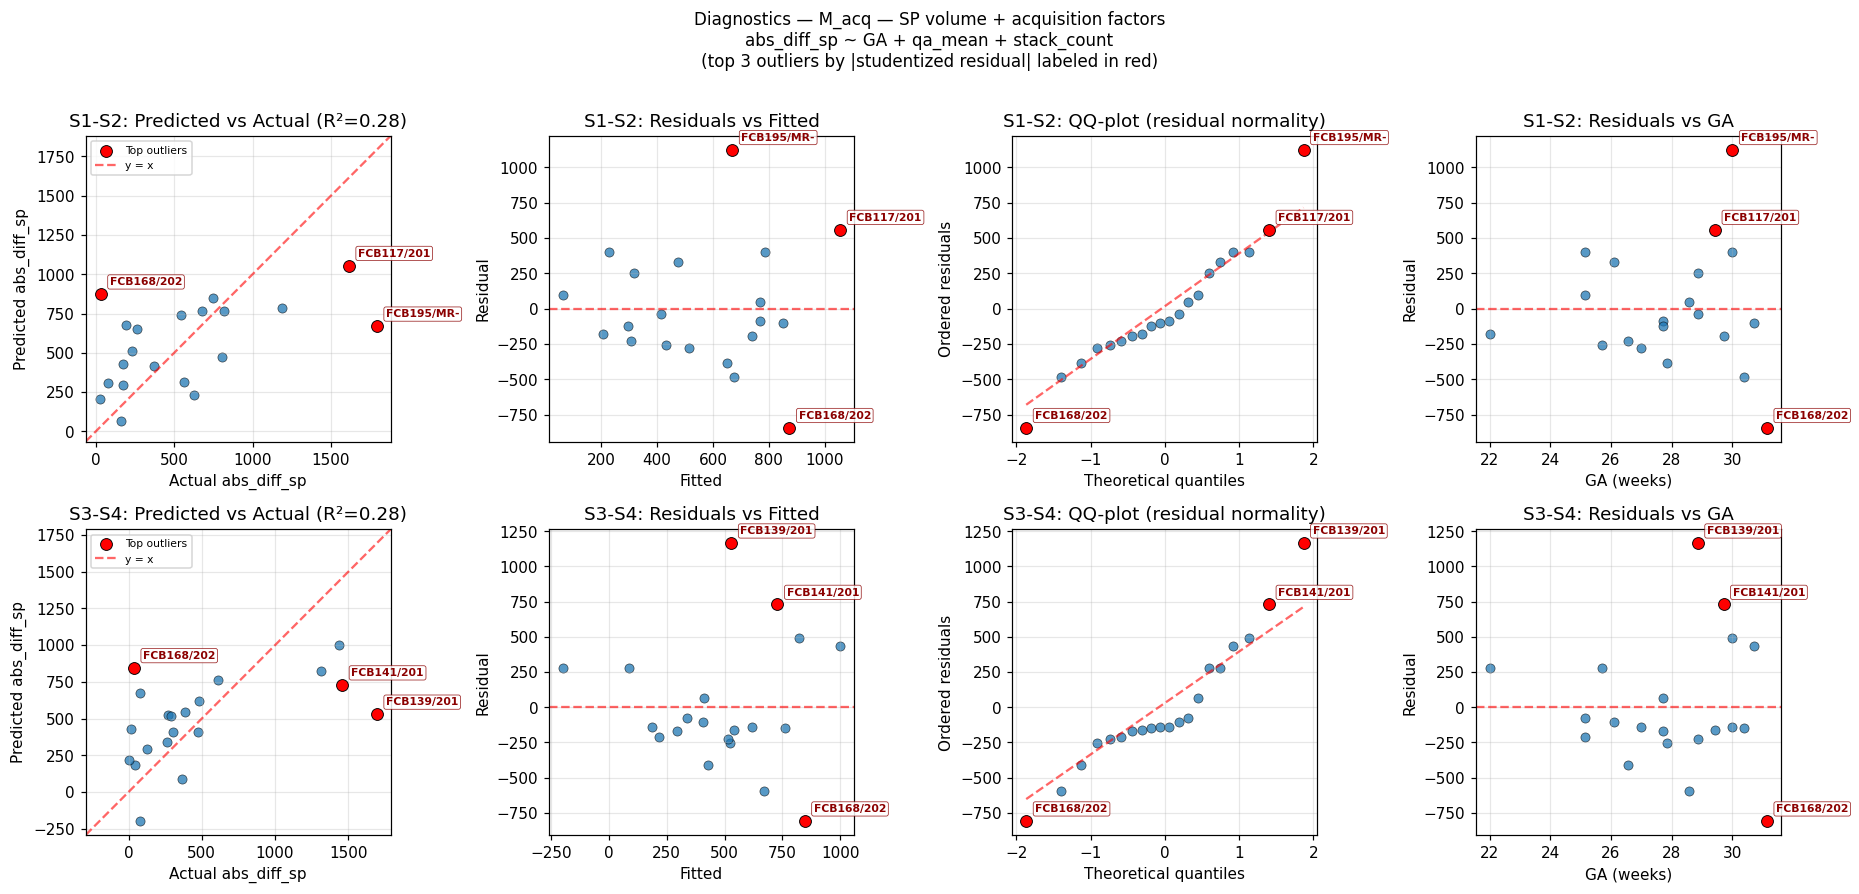

In [7]:
diagnostics_grid(
    vol_results['M_acq (vol)'], s12, s34,
    'abs_diff_sp', ['GA', 'qa_mean', 'stack_count'],
    'M_acq — SP volume + acquisition factors',
)
plt.show()

## Surface area models

Same structure as the volume models:

1. **S_GA**: `wm_surface_area_diff ~ GA`
2. **S_acq**: `wm_surface_area_diff ~ GA + qa_mean + stack_count`


===  | S1-S2 | R²=0.037 | F=0.70 | p=0.4154 | N=20 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-712.280,1125.993,-0.630,0.535,-3077.900,1653.340,
GA,33.499,40.182,0.830,0.415,-50.920,117.920,



===  | S3-S4 | R²=0.052 | F=1.00 | p=0.3317 | N=20 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-251.828,379.817,-0.660,0.516,-1049.790,546.140,
GA,13.521,13.554,1.000,0.332,-14.950,42.000,


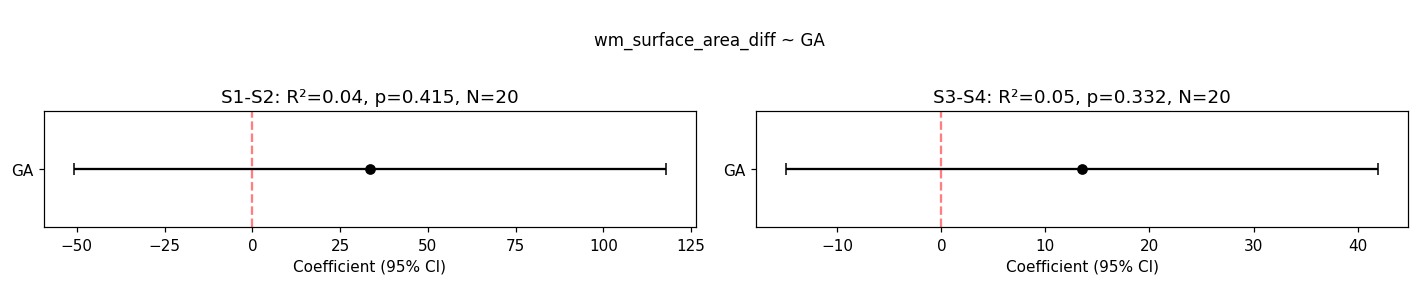

In [8]:
surf_results = {}

surf_results['S_GA (surf)'] = fit_and_present(
    'wm_surface_area_diff', ['GA'], s12, s34,
    '', 'surf_S_GA', ASSETS,
)


[S_GA — WM surface area baseline] S1-S2 — top 3 outliers (|studentized residual|):
  1. 4712320/MR-EI_Fetal_Body-26831832-20230502  studentized_resid=+3.44  resid=+1.32e+03  fitted=306  actual=1.62e+03
  2. 1109332/MR-EI_Fetal_Body-26810110-20230404  studentized_resid=+2.14  resid=+843  fitted=192  actual=1.04e+03
  3. FCB168/2020.03.12-021Y-MR_EI_Fetal_Neuro-30926  studentized_resid=-0.79  resid=-296  fitted=331  actual=35

[S_GA — WM surface area baseline] S3-S4 — top 3 outliers (|studentized residual|):
  1. 1109332/MR-EI_Fetal_Body-26810110-20230404  studentized_resid=+3.73  resid=+496  fitted=113  actual=609
  2. FCB147/2019.05.08-036Y-MR_EI_Fetal_Neuro-29187  studentized_resid=-0.89  resid=-113  fitted=163  actual=50
  3. FCB105-B/2018.11.14-036Y-MR_EI_Fetal_Neuro-29459  studentized_resid=-0.81  resid=-108  fitted=125  actual=16.5


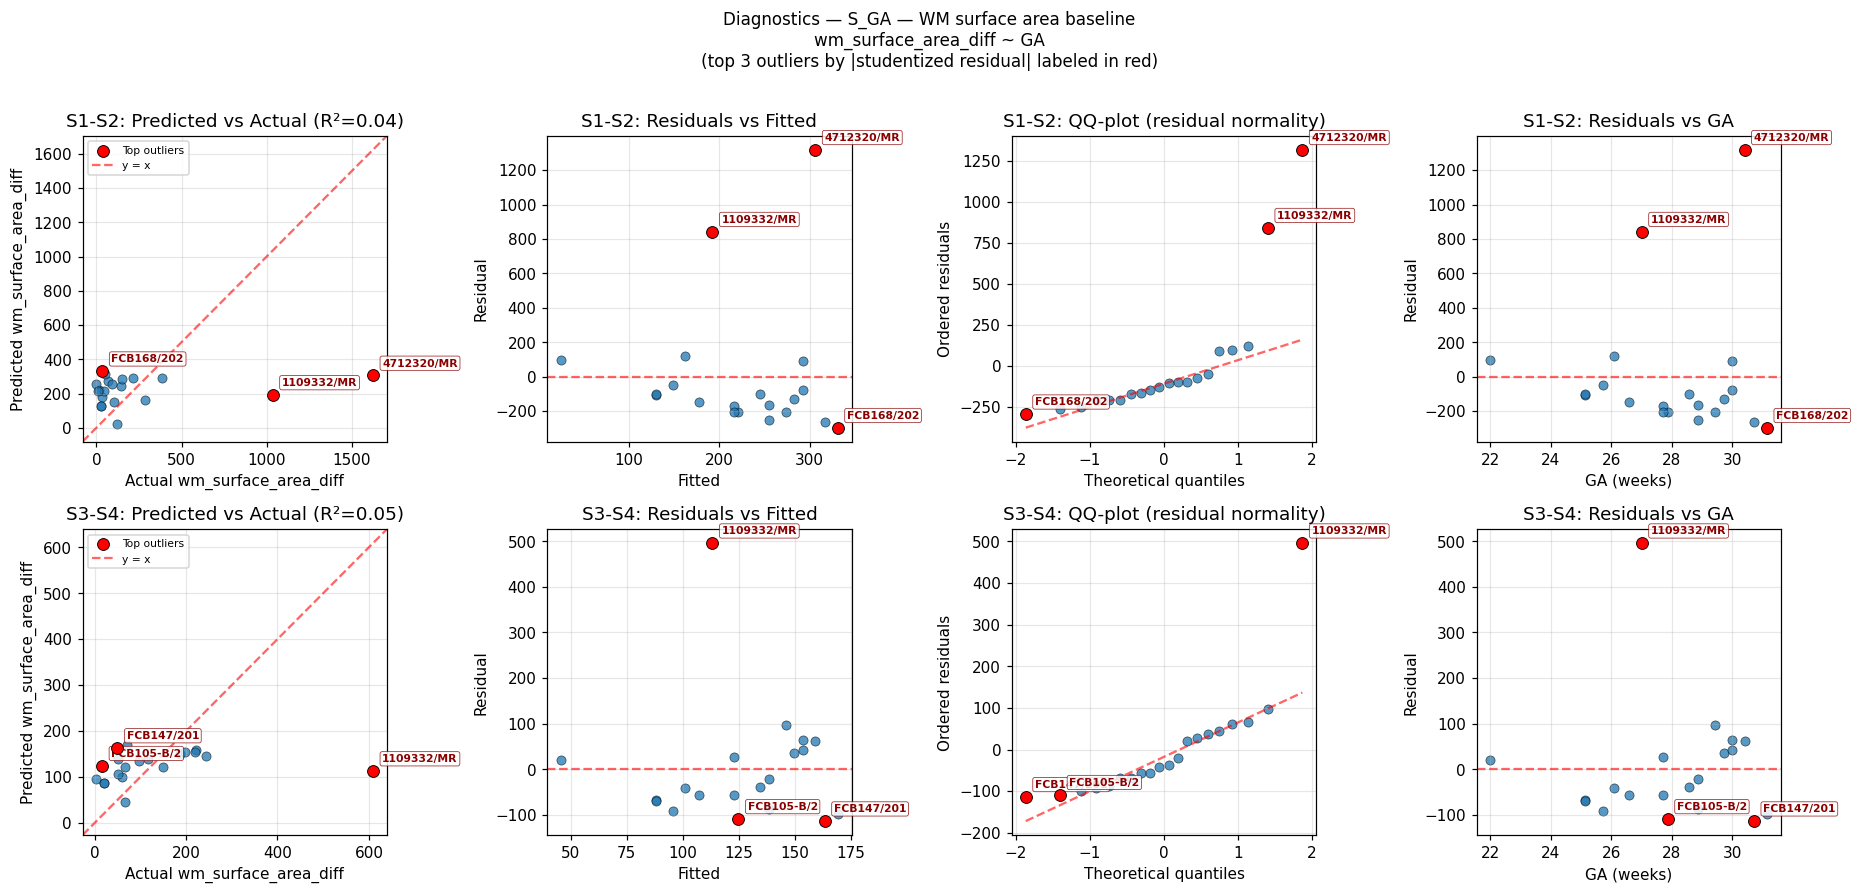

In [9]:
diagnostics_grid(
    surf_results['S_GA (surf)'], s12, s34,
    'wm_surface_area_diff', ['GA'],
    'S_GA — WM surface area baseline',
)
plt.show()


===  | S1-S2 | R²=0.116 | F=0.70 | p=0.5671 | N=20 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-8.258,1312.158,-0.010,0.995,-2789.910,2773.390,
GA,27.164,41.330,0.660,0.520,-60.450,114.780,
qa_mean,-368.811,650.699,-0.570,0.579,-1748.230,1010.610,
stack_count,-41.884,35.335,-1.190,0.253,-116.790,33.020,



===  | S3-S4 | R²=0.299 | F=2.28 | p=0.1186 | N=20 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,195.143,394.381,0.490,0.627,-640.910,1031.190,
GA,13.577,12.591,1.080,0.297,-13.110,40.270,
qa_mean,-463.204,243.337,-1.900,0.075,-979.060,52.650,
stack_count,-22.680,10.871,-2.090,0.053,-45.730,0.370,


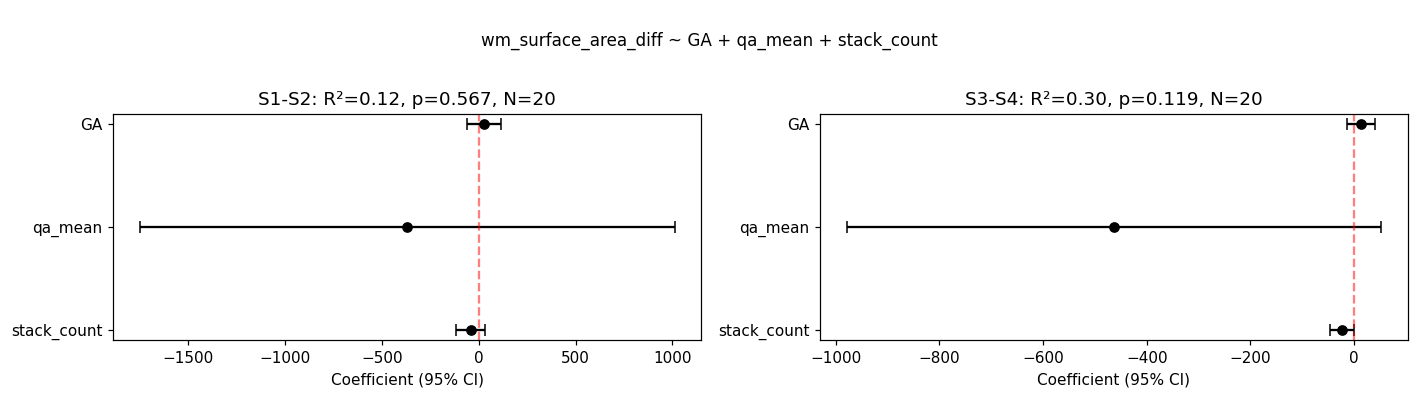

In [10]:
surf_results['S_acq (surf)'] = fit_and_present(
    'wm_surface_area_diff', ['GA', 'qa_mean', 'stack_count'], s12, s34,
    '', 'surf_S_acq', ASSETS,
)


[S_acq — WM surface + acquisition factors] S1-S2 — top 3 outliers (|studentized residual|):
  1. 4712320/MR-EI_Fetal_Body-26831832-20230502  studentized_resid=+3.34  resid=+1.29e+03  fitted=339  actual=1.62e+03
  2. 1109332/MR-EI_Fetal_Body-26810110-20230404  studentized_resid=+1.77  resid=+635  fitted=400  actual=1.04e+03
  3. FCB130/2018.11.02-030Y-MR_EI_Fetal_Neuro-29188  studentized_resid=-1.01  resid=-349  fitted=395  actual=45.8

[S_acq — WM surface + acquisition factors] S3-S4 — top 3 outliers (|studentized residual|):
  1. 1109332/MR-EI_Fetal_Body-26810110-20230404  studentized_resid=+3.47  resid=+384  fitted=225  actual=609
  2. FCB191/MR-EI_Fetal_Neuro-26708033-20230113  studentized_resid=-1.61  resid=-181  fitted=185  actual=4.17
  3. FCB149/2019.04.11-030Y-MR_EI_Fetal_Neuro-29205  studentized_resid=-1.05  resid=-121  fitted=172  actual=50.7


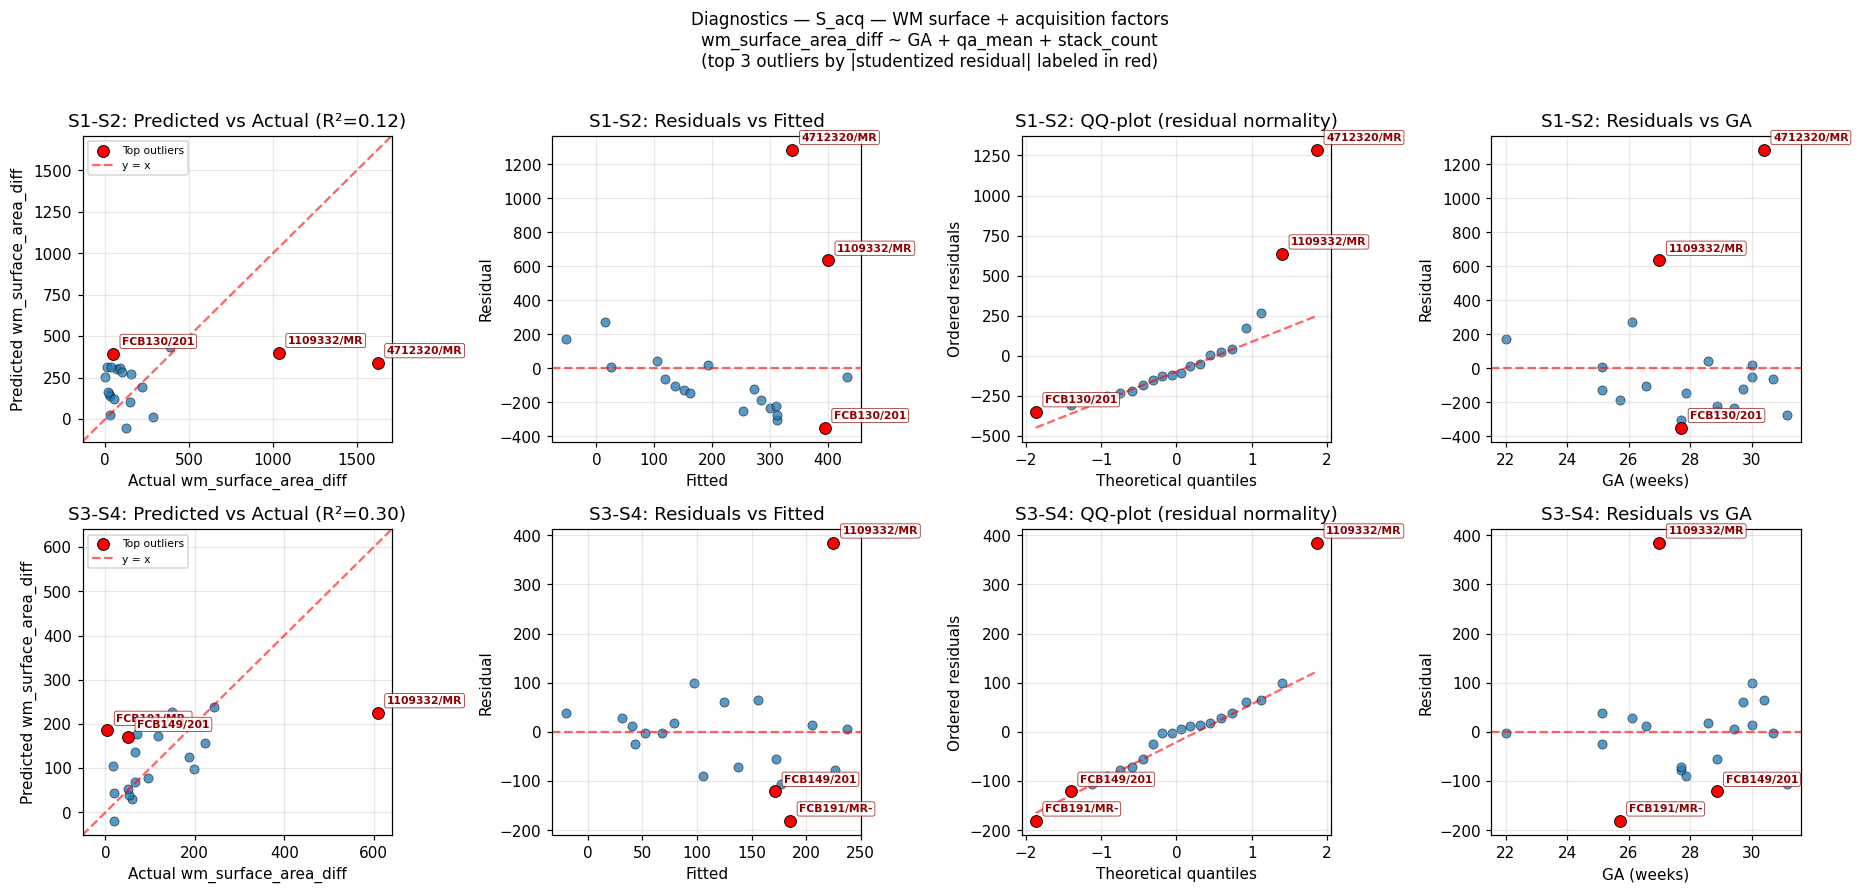

In [11]:
diagnostics_grid(
    surf_results['S_acq (surf)'], s12, s34,
    'wm_surface_area_diff', ['GA', 'qa_mean', 'stack_count'],
    'S_acq — WM surface + acquisition factors',
)
plt.show()

## Cross-model comparison

Side-by-side R², GA effect across all six models × both pairs. Read column-wise: a model is *consistent* if its R², GA-sign, and GA-significance look similar across S1-S2 and S3-S4.

,model,pair,N,R2,adj_R2,F_p,GA_coef,GA_p
0,M_GA (vol),S1-S2,20,0.160,0.113,0.081,86.925,0.081
1,M_GA (vol),S3-S4,20,0.239,0.197,0.029,113.639,0.029
2,M_acq (vol),S1-S2,20,0.280,0.145,0.144,94.333,0.060
3,M_acq (vol),S3-S4,20,0.284,0.149,0.139,115.031,0.035
4,S_GA (surf),S1-S2,20,0.037,-0.016,0.415,33.499,0.415
5,S_GA (surf),S3-S4,20,0.052,-0.000,0.332,13.521,0.332
6,S_acq (surf),S1-S2,20,0.116,-0.050,0.567,27.164,0.520
7,S_acq (surf),S3-S4,20,0.299,0.168,0.119,13.577,0.297


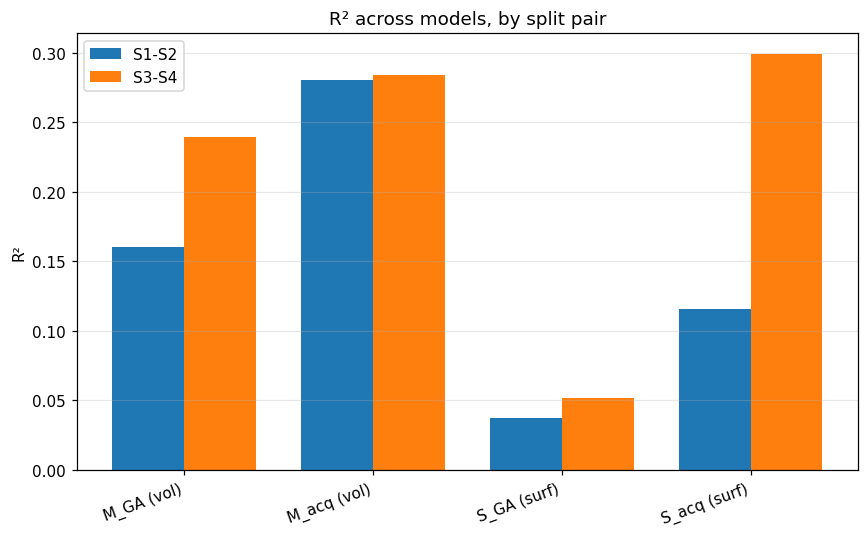

Saved → assets/model_comparison_table.csv, assets/model_comparison_R2.png


In [12]:
all_results = {**vol_results, **surf_results}
comparison = model_comparison_table(all_results)
comparison.to_csv(ASSETS / 'model_comparison_table.csv', index=False)
display(comparison)

# R² bar chart, paired by split
fig, ax = plt.subplots(figsize=(8, 5))
models = comparison['model'].unique()
x = np.arange(len(models))
w = 0.38
for i, pair in enumerate(['S1-S2', 'S3-S4']):
    sub = comparison[comparison['pair'] == pair].set_index('model').reindex(models)
    ax.bar(x + (i - 0.5) * w, sub['R2'], width=w, label=pair)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_ylabel('R²'); ax.set_title('R² across models, by split pair')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(ASSETS / 'model_comparison_R2.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → assets/model_comparison_table.csv, assets/model_comparison_R2.png')

## Common outliers across models

For each (model × pair), recompute the top-N outliers by |studentized residual| and aggregate.
A subject/session that flags as an outlier in multiple model fits is more likely a true
data-quality issue than a model-specific quirk. The table below lists every subject/session
flagged in **more than one** (model, pair) combination, along with its acquisition
covariates and both outcomes for each pair.

In [13]:
import statsmodels.api as sm

N_OUTLIERS = 3  # top-N per (model, pair) by |studentized residual|

# Per-model outcome + predictors — kept here so we can recompute residuals
# exactly as fit_and_present / diagnostics_grid did.
MODEL_SPECS = {
    'M_GA (vol)':    ('abs_diff_sp',          ['GA']),
    'M_acq (vol)':   ('abs_diff_sp',          ['GA', 'qa_mean', 'stack_count']),
    'S_GA (surf)':   ('wm_surface_area_diff', ['GA']),
    'S_acq (surf)':  ('wm_surface_area_diff', ['GA', 'qa_mean', 'stack_count']),
}

PAIR_FRAMES = {'S1-S2': s12, 'S3-S4': s34}


def _top_outliers(res, df, outcome, predictors, n):
    keep = [outcome] + predictors + ['subject_id', 'session_id']
    sub = df[keep].dropna(subset=[outcome] + predictors).reset_index(drop=True)
    student = res.get_influence().resid_studentized_internal
    idx = np.argsort(np.abs(student))[-n:][::-1]
    out = sub.iloc[idx].copy()
    out['studentized_resid'] = student[idx]
    return out[['subject_id', 'session_id', 'studentized_resid']]


# Collect (model, pair, subject_id, session_id, studentized_resid) for every flagged point
records = []
for model_label, by_pair in all_results.items():
    outcome, predictors = MODEL_SPECS[model_label]
    for pair, (res, _) in by_pair.items():
        flagged = _top_outliers(res, PAIR_FRAMES[pair], outcome, predictors, N_OUTLIERS)
        for _, row in flagged.iterrows():
            records.append({
                'subject_id': row['subject_id'],
                'session_id': row['session_id'],
                'model': model_label,
                'pair': pair,
                'studentized_resid': row['studentized_resid'],
            })

flagged_df = pd.DataFrame(records)

# Count how many distinct (model, pair) combos flagged each subject/session
counts = (
    flagged_df.groupby(['subject_id', 'session_id'])
    .size()
    .reset_index(name='n_flags')
    .sort_values('n_flags', ascending=False)
)

common = counts[counts['n_flags'] > 1].copy()
print(f"Subjects flagged in >1 (model, pair): {len(common)} / {len(counts)} total flagged")
display(common)

# Build a per-subject info block: covariates + outcomes for each pair
info_cols_pair = ['abs_diff_sp', 'apd_sp', 'wm_surface_area_diff', 'apd_surface',
                  'wm_surface_area_mean', 'cnr_mean', 'qa_mean', 'stack_count']

def _subject_info(sid, ses):
    blocks = []
    for pair, df in PAIR_FRAMES.items():
        row = df[(df['subject_id'] == sid) & (df['session_id'] == ses)]
        if row.empty:
            continue
        r = row.iloc[0]
        ga = r.get('GA', float('nan'))
        parts = [f"  {pair}: GA={ga:.1f}w"]
        for c in info_cols_pair:
            if c in row.columns:
                v = r[c]
                parts.append(f"{c}={v:.3g}" if pd.notna(v) else f"{c}=NA")
        blocks.append('  '.join(parts))
    return blocks


for _, row in common.iterrows():
    sid, ses, n = row['subject_id'], row['session_id'], row['n_flags']
    print(f"\n=== {sid}/{ses}  —  flagged in {n} (model, pair) combos ===")
    sub_flags = (flagged_df[(flagged_df['subject_id'] == sid)
                            & (flagged_df['session_id'] == ses)]
                 .sort_values(['model', 'pair']))
    for _, f in sub_flags.iterrows():
        print(f"  [{f['model']:<14}] {f['pair']}  studentized_resid={f['studentized_resid']:+.2f}")
    print("  ---")
    for block in _subject_info(sid, ses):
        print(block)

flagged_df.to_csv(ASSETS / 'outliers_per_model.csv', index=False)
common.to_csv(ASSETS / 'common_outliers.csv', index=False)
print('\nSaved → assets/outliers_per_model.csv, assets/common_outliers.csv')

Subjects flagged in >1 (model, pair): 7 / 12 total flagged


,subject_id,session_id,n_flags
9,FCB168,2020.03.12-021Y-MR_EI_Fetal_Neuro-30926,5
0,1109332,MR-EI_Fetal_Body-26810110-20230404,4
3,FCB117,2018.03.01-032Y-MR_EI_Fetal_Neuro-18053,2
1,4712320,MR-EI_Fetal_Body-26831832-20230502,2
11,FCB195,MR-EI_Fetal_Neuro-26792482-20230322,2
5,FCB139,2019.01.31-032Y-MR_EI_Fetal_Neuro-29172,2
6,FCB141,2019.04.03-032Y-MR_EI_Fetal_Neuro-29199,2



=== FCB168/2020.03.12-021Y-MR_EI_Fetal_Neuro-30926  —  flagged in 5 (model, pair) combos ===
  [M_GA (vol)    ] S1-S2  studentized_resid=-1.83
  [M_GA (vol)    ] S3-S4  studentized_resid=-1.83
  [M_acq (vol)   ] S1-S2  studentized_resid=-1.97
  [M_acq (vol)   ] S3-S4  studentized_resid=-1.78
  [S_GA (surf)   ] S1-S2  studentized_resid=-0.79
  ---
  S1-S2: GA=31.1w  abs_diff_sp=31  apd_sp=0.0707  wm_surface_area_diff=35  apd_surface=0.12  wm_surface_area_mean=2.9e+04  cnr_mean=0.00498  qa_mean=0.63  stack_count=7
  S3-S4: GA=31.1w  abs_diff_sp=36.7  apd_sp=0.0832  wm_surface_area_diff=70.5  apd_surface=0.243  wm_surface_area_mean=2.91e+04  cnr_mean=0.00372  qa_mean=0.61  stack_count=7

=== 1109332/MR-EI_Fetal_Body-26810110-20230404  —  flagged in 4 (model, pair) combos ===
  [S_GA (surf)   ] S1-S2  studentized_resid=+2.14
  [S_GA (surf)   ] S3-S4  studentized_resid=+3.73
  [S_acq (surf)  ] S1-S2  studentized_resid=+1.77
  [S_acq (surf)  ] S3-S4  studentized_resid=+3.47
  ---
  S1-S2: G